In [55]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping

In [56]:
dataset_train = pd.read_csv('Google_Stock_Price_Train.csv')
dataset_train

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"
...,...,...,...,...,...,...
1253,12/23/2016,790.90,792.74,787.28,789.91,"623,400"
1254,12/27/2016,790.68,797.86,787.66,791.55,"789,100"
1255,12/28/2016,793.70,794.23,783.20,785.05,"1,153,800"
1256,12/29/2016,783.33,785.93,778.92,782.79,"744,300"


In [57]:
dataset_train.shape

(1258, 6)

In [58]:
training_set = dataset_train.iloc[:, 1:2].values
training_set

array([[325.25],
       [331.27],
       [329.83],
       ...,
       [793.7 ],
       [783.33],
       [782.75]])

In [59]:
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)
training_set_scaled

array([[0.08581368],
       [0.09701243],
       [0.09433366],
       ...,
       [0.95725128],
       [0.93796041],
       [0.93688146]])

In [60]:
X_train = []
y_train = []
for i in range(60, 1258):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = pd.array(X_train), pd.array(y_train)

In [61]:
X_train

<NumpyExtensionArray>
[array([0.08581368, 0.09701243, 0.09433366, 0.09156187, 0.07984225,
       0.0643277 , 0.0585423 , 0.06568569, 0.06109085, 0.06639259,
       0.0614257 , 0.07474514, 0.02797827, 0.02379269, 0.02409033,
       0.0159238 , 0.01078949, 0.00967334, 0.01642607, 0.02100231,
       0.02280676, 0.02273235, 0.02810849, 0.03212665, 0.0433812 ,
       0.04475779, 0.04790163, 0.0440695 , 0.04648783, 0.04745517,
       0.04873875, 0.03936305, 0.04137213, 0.04034898, 0.04784582,
       0.04325099, 0.04356723, 0.04286033, 0.04602277, 0.05398467,
       0.05738894, 0.05714711, 0.05569611, 0.04421832, 0.04514845,
       0.04605997, 0.04412531, 0.03675869, 0.04486941, 0.05065481,
       0.05214302, 0.05612397, 0.05818885, 0.06540665, 0.06882953,
       0.07243843, 0.07993526, 0.07846566, 0.08034452, 0.08497656]),
 array([0.09701243, 0.09433366, 0.09156187, 0.07984225, 0.0643277 ,
       0.0585423 , 0.06568569, 0.06109085, 0.06639259, 0.0614257 ,
       0.07474514, 0.02797827, 0.023

In [62]:
y_train

<FloatingArray>
[0.08627874097775134, 0.08471612471166012, 0.07454051640747084,
 0.07883771113922167, 0.07238261775429711, 0.06663442220403304,
 0.06315574075452046, 0.06782498697819772, 0.06823424361931696,
 0.07601011980058048,
 ...
  0.9697150085571844,  0.9507775876181264,  0.9629436714041224,
  0.9612322345412607,  0.9547585385817399,  0.9520425626906763,
  0.9516333060495572,  0.9572512835776472,  0.9379604137212592,
  0.9368814643946723]
Length: 1198, dtype: Float64

In [63]:
# Reshape X_train to the correct shape
X_train = np.array(X_train.tolist())
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_train.shape

(1198, 60, 1)

In [64]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/Users/caio.motta/.pyenv/versions/3.11.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
model.fit(X_train, y_train, epochs=500, batch_size=32, callbacks=[EarlyStopping(monitor='loss', patience=10)])

Epoch 1/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0915
Epoch 2/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0064
Epoch 3/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0065
Epoch 4/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0054
Epoch 5/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0054
Epoch 6/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0051
Epoch 7/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0045
Epoch 8/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0044
Epoch 9/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0043
Epoch 10/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0043
Epoch 11/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0041
Epoch 12/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0039
Epoch 13/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0043
Epoch 14/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0037
Epoch 15/500
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - lo

In [66]:
dataset_test = pd.read_csv('Google_Stock_Price_Test.csv')
real_stock_price = dataset_test.iloc[:, 1:2].values
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)
X_test = []
for i in range(60, 80):
  X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predicted_stock_price = model.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)
predicted_stock_price

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step


array([[767.6602 ],
       [765.2595 ],
       [770.05756],
       [770.6168 ],
       [774.9254 ],
       [782.6659 ],
       [785.1943 ],
       [783.26953],
       [784.03705],
       [785.4201 ],
       [786.0508 ],
       [785.7437 ],
       [785.48535],
       [786.72754],
       [787.49445],
       [796.4526 ],
       [803.3371 ],
       [808.7649 ],
       [807.64465],
       [795.5678 ]], dtype=float32)

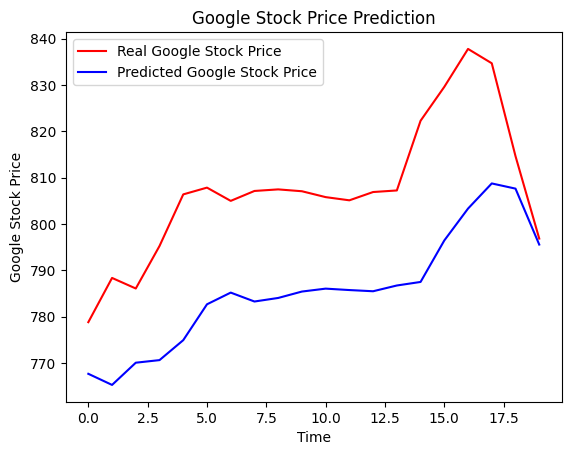

In [67]:
plt.plot(real_stock_price, color='red', label='Real Google Stock Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()